In [1]:
import importlib
import camera_model
import plotting

importlib.reload(camera_model)
importlib.reload(plotting)

from camera_model import transform_scene_to_cam1, get_relative_pose
from plotting import plot_top_view_scene

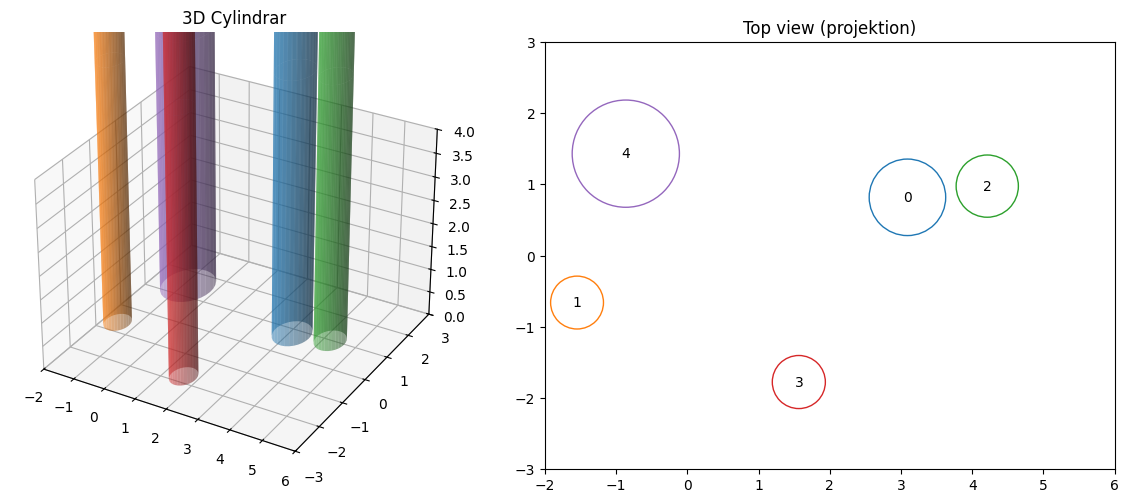

In [2]:
from cylinder_generator import generate_cylinders
from camera_model import compute_camera_pair
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Generera data
# -----------------------
cylinders, bounds= generate_cylinders(seed=12)  # seed=10
(xmin, xmax, ymin, ymax) = bounds

# färger
cmap = plt.get_cmap("tab10")
colors = {i: plt.cm.tab10(i % 10) for i in range(100)}

# -----------------------
# Plot
# -----------------------
fig = plt.figure(figsize=(12, 5))

# --- 3D plot ---
ax3d = fig.add_subplot(1, 2, 1, projection='3d')

theta = np.linspace(0, 2*np.pi, 30)

for i, (x, y, _, r, h) in enumerate(cylinders):
    z = np.linspace(0, h, 10)
    theta_grid, z_grid = np.meshgrid(theta, z)

    X = x + r * np.cos(theta_grid)
    Y = y + r * np.sin(theta_grid)
    Z = z_grid

    ax3d.plot_surface(X, Y, Z, color=colors[i], alpha=0.5)

    # centrum
    ax3d.text(x, y, h, str(i))

ax3d.set_title("3D Cylindrar")
ax3d.set_xlim(xmin, xmax)
ax3d.set_ylim(ymin, ymax)
ax3d.set_zlim(0, 4)

# --- Top view (2D) ---
ax2d = fig.add_subplot(1, 2, 2)

for i, (x, y, _, r, h) in enumerate(cylinders):
    circ = plt.Circle((x, y), r, fill=False, color=colors[i])
    ax2d.add_patch(circ)
    ax2d.text(x, y, str(i), ha='center', va='center')

ax2d.set_aspect('equal')
ax2d.set_xlim(xmin, xmax)
ax2d.set_ylim(ymin, ymax)
ax2d.set_title("Top view (projektion)")

plt.tight_layout()
plt.show()

Kamera 1 ser cylindrar: [0, 1, 2, 3]
Kamera 2 ser cylindrar: [0, 1, 2, 3, 4]


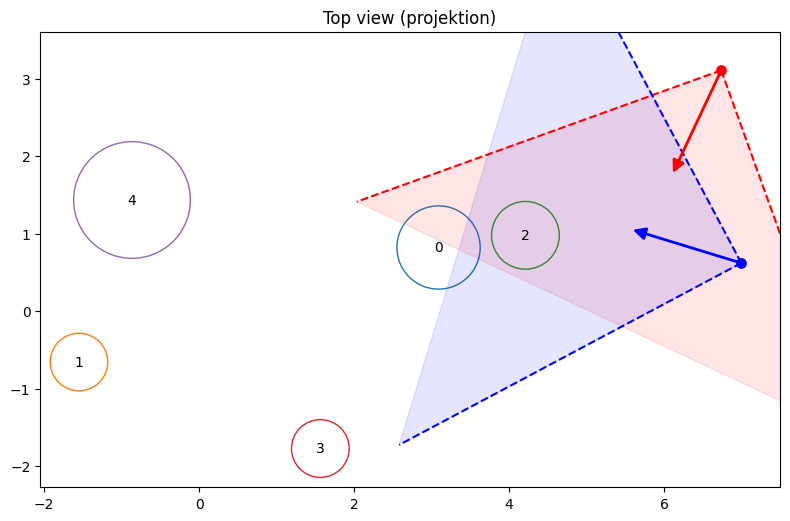

In [3]:
from camera_model import compute_camera_pair, in_fov, compute_projections

cam1, cam2 = compute_camera_pair(
    cylinders,
    bounds,
    seed=20,
    camera_distance=2.5,
)

def visible_cylinders(cam, cylinders):
    visible = []
    for i, (x, y, _, r, h) in enumerate(cylinders):
        center = np.array([x, y, h / 2])
        if in_fov(cam, center):
            visible.append(i)
    return visible

vis1 = visible_cylinders(cam1, cylinders)
vis2 = visible_cylinders(cam2, cylinders)

print("Kamera 1 ser cylindrar:", vis1)
print("Kamera 2 ser cylindrar:", vis2)

fig, ax = plt.subplots(figsize=(8, 6))
plot_top_view_scene(ax, cylinders, cam1, cam2, colors=colors, title="Top view (projektion)")
plt.tight_layout()
plt.show()

[-8.32667268e-17  0.00000000e+00  0.00000000e+00  1.00000000e+00]


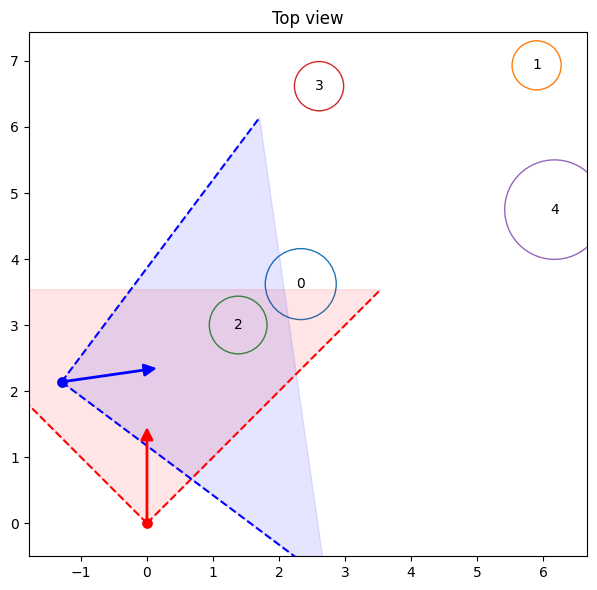

In [4]:
cam1_n, cam2_n, cylinders_n = transform_scene_to_cam1(cam1, cam2, cylinders)
rel_pose = get_relative_pose(cam1_n, cam2_n)

def camera_pose_matrix(cam):
    R = np.column_stack([cam.right, cam.dir, cam.up])
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = cam.c
    return T

def camera_extrinsic_matrix(cam):
    R = np.column_stack([cam.right, cam.dir, cam.up])
    Rt = R.T
    t = -Rt @ cam.c

    T = np.eye(4)
    T[:3, :3] = Rt
    T[:3, 3] = t
    return T

if False:
    print(rel_pose["R_cam1_to_cam2"])
    print(rel_pose["t_cam1_to_cam2"])

    print("========== CAMERAS BEFORE ================")
    print("Cam1 pose:\n", camera_pose_matrix(cam1))
    print("Cam2 pose:\n", camera_pose_matrix(cam2))

    print("========== CAMERAS AFTER ================")
    print("Cam1_n pose:\n", camera_pose_matrix(cam1_n))
    print("Cam2_n pose:\n", camera_pose_matrix(cam2_n))

    print("========== EXTRINSISICS ================")
    print("Cam1 extrinsic:\n", camera_extrinsic_matrix(cam1))
    print("Cam2 extrinsic:\n", camera_extrinsic_matrix(cam2))
    print("Cam1_n extrinsic:\n", camera_extrinsic_matrix(cam1_n))
    print("Cam2_n extrinsic:\n", camera_extrinsic_matrix(cam2_n))

T = camera_extrinsic_matrix(cam2_n)
p_cam = T @ np.append(cam2_n.c, 1)

print(p_cam)


fig, ax = plt.subplots(figsize=(8, 6))
plot_top_view_scene(ax, cylinders_n, cam1_n, cam2_n, colors=colors, title="Top view")

plt.tight_layout()
plt.show()

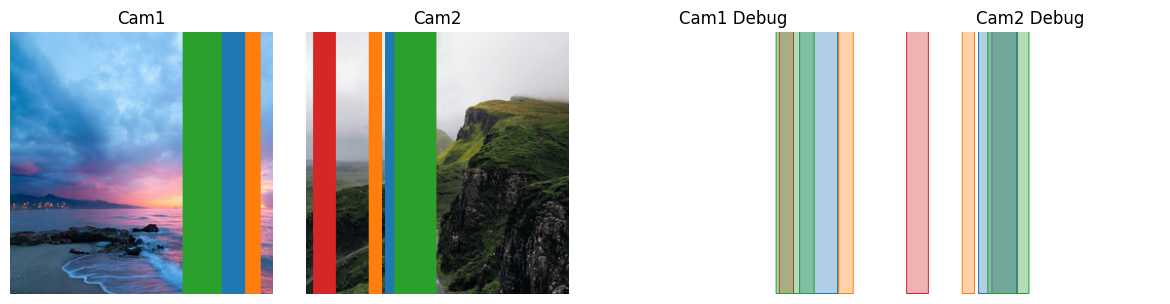

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

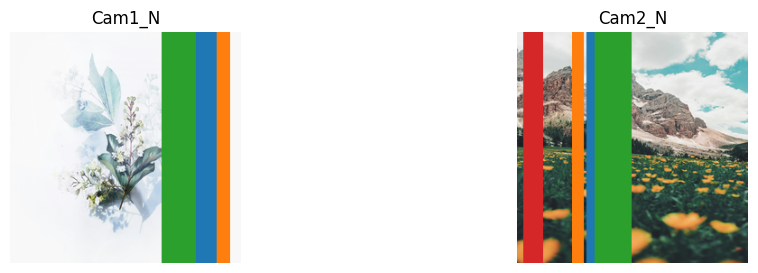

In [5]:
from render import render_camera_image, render_camera_image_debug

proj1, proj2 = compute_projections(cam1, cam2, cylinders)

# rendera bilder
img1 = render_camera_image(proj1, colors)
img2 = render_camera_image(proj2, colors)

proj1_n, proj2_n = compute_projections(cam1_n, cam2_n, cylinders_n)

img1_n = render_camera_image(proj1_n, colors)
img2_n = render_camera_image(proj2_n, colors)

img1_debug = render_camera_image_debug(proj1, colors)
img2_debug = render_camera_image_debug(proj2, colors)

# -----------------------
# Plot alla tillsammans
# -----------------------
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

# Camera 1
axs[0].imshow(img1)
axs[0].set_title("Cam1")
axs[0].axis("off")

# Camera 2
axs[1].imshow(img2)
axs[1].set_title("Cam2")
axs[1].axis("off")

# Debug Camera 1
axs[2].imshow(img1_debug)
axs[2].set_title("Cam1 Debug")
axs[2].axis("off")

# Debug Camera 2
axs[3].imshow(img2_debug)
axs[3].set_title("Cam2 Debug")
axs[3].axis("off")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 3))

# Camera 1
axs[0].imshow(img1_n)
axs[0].set_title("Cam1_N")
axs[0].axis("off")

# Camera 2
axs[1].imshow(img2_n)
axs[1].set_title("Cam2_N")
axs[1].axis("off")




In [6]:
from vision import build_vision_pair

mat1, mat2 = build_vision_pair(proj1_n, proj2_n, cylinders_n, cam1=cam1_n, cam2=cam2_n)

print(cylinders_n[0][3], cylinders_n[1][3], cylinders_n[2][3], cylinders_n[3][3], cylinders_n[4][3])
print(mat1[:,1])
print(mat2[:,1])

0.537285339344274 0.3713001764626839 0.4370240697391657 0.3726513973550515 0.7529864907646613
[0.         0.3713002  0.         0.         0.5372853  0.
 0.         0.43702406 0.3726514  0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.43702406 0.         0.5372853  0.         0.
 0.         0.3713002  0.         0.         0.         0.
 0.3726514  0.        ]


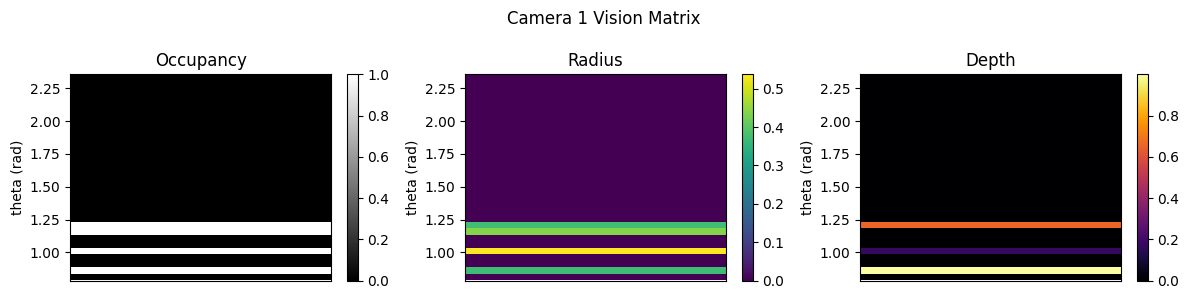

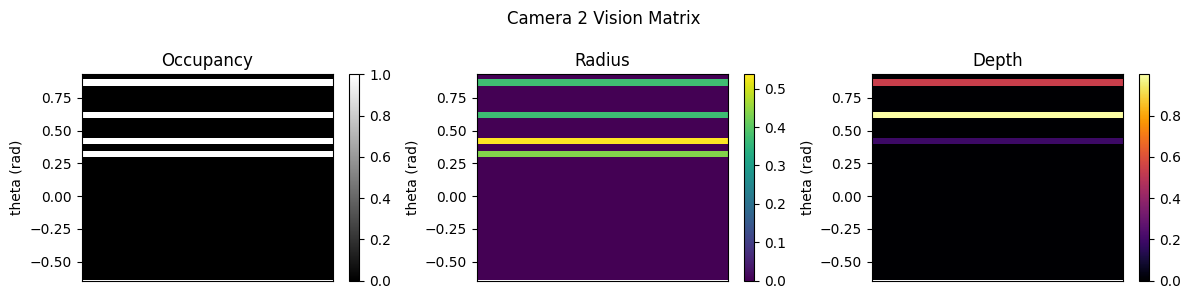

In [7]:
def plot_vision_matrix(mat, title, theta_center=np.pi / 2, fov_degrees=90.0):
    fig, axs = plt.subplots(1, 3, figsize=(12, 3))
    
    labels = ["Occupancy", "Radius", "Depth"]
    cmaps = ['gray', 'viridis', 'inferno']
    
    num_bins = mat.shape[0]
    theta_half = np.deg2rad(fov_degrees) / 2
    theta_min = theta_center - theta_half
    theta_max = theta_center + theta_half

    # --- normalisera depth för bättre kontrast ---
    depth = mat[:, 2]
    if np.any(depth > 0):
        depth_norm = depth.copy()
        mask = depth > 0
        depth_norm[mask] = (depth[mask] - np.min(depth[mask])) / (np.max(depth[mask]) - np.min(depth[mask]) + 1e-6)
    else:
        depth_norm = depth

    # skapa temporär matris för plotting
    mat_plot = np.stack([
        mat[:, 0],            # occupancy
        mat[:, 1],            # radius
        depth_norm            # normalized depth
    ], axis=1)

    for i in range(3):
        data = mat_plot[:, i].reshape(-1, 1)
        
        im = axs[i].imshow(
            data,
            aspect='auto',
            origin='lower',
            extent=[0, 1, theta_min, theta_max],
            cmap=cmaps[i]
        )
        
        axs[i].set_title(labels[i])
        axs[i].set_ylabel("theta (rad)")
        axs[i].set_xticks([])
        
        plt.colorbar(im, ax=axs[i])

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# -----------------------
# Plot för båda kameror
# -----------------------
plot_vision_matrix(mat1, "Camera 1 Vision Matrix", theta_center=cam1_n.theta_xy)
plot_vision_matrix(mat2, "Camera 2 Vision Matrix", theta_center=cam2_n.theta_xy)

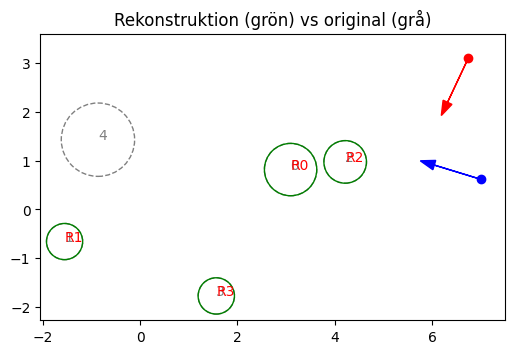

In [8]:
# -----------------------
# Hjälpfunktioner
# -----------------------
def ray_from_camera(cam, u):
    """
    Skapa ray från kamera baserat på u (bildkoordinat)
    """
    # riktning i värld: dir + u * right
    d = cam.dir + u * cam.right
    d = d / np.linalg.norm(d)

    # vi jobbar i XY-plan → ta bort z
    d_xy = d[:2]
    d_xy = d_xy / np.linalg.norm(d_xy)

    return cam.c[:2], d_xy


def intersect_rays(p1, d1, p2, d2):
    A = np.stack([d1, -d2], axis=1)
    b = p2 - p1

    if np.linalg.matrix_rank(A) < 2:
        return None

    t = np.linalg.lstsq(A, b, rcond=None)[0]

    pt1 = p1 + t[0] * d1
    pt2 = p2 + t[1] * d2

    return 0.5 * (pt1 + pt2)


# -----------------------
# Rekonstruktion
# -----------------------
reconstructed = []

# matcha på index (fortfarande enkelt case)
for (i1, umin1, umax1, *_ ) in proj1:
    for (i2, umin2, umax2, *_ ) in proj2:

        if i1 != i2:
            continue

        # använd mitten av intervallet
        u1 = 0.5 * (umin1 + umax1)
        u2 = 0.5 * (umin2 + umax2)

        p1, d1 = ray_from_camera(cam1, u1)
        p2, d2 = ray_from_camera(cam2, u2)

        pt = intersect_rays(p1, d1, p2, d2)

        if pt is None:
            continue

        # radie från cylinder
        r = cylinders[i1][3]

        reconstructed.append((pt[0], pt[1], r, i1))


# -----------------------
# Plot jämförelse (top view)
# -----------------------
fig, ax = plt.subplots(figsize=(6,6))

# original cylindrar (top view)
for i, (x, y,_, r, h) in enumerate(cylinders):
    circ = plt.Circle((x, y), r, fill=False, linestyle='--', color='gray')
    ax.add_patch(circ)
    ax.text(x, y, str(i), color='gray')

# rekonstruerade
for x, y, r, idx in reconstructed:
    circ = plt.Circle((x, y), r, fill=False, color='green')
    ax.add_patch(circ)
    ax.text(x, y, f"R{idx}", color='red')

# kameror
def draw_camera(ax, cam, color):
    c = cam.c[:2]
    d = cam.dir[:2]
    d = d / np.linalg.norm(d)
    ax.plot(c[0], c[1], 'o', color=color)
    ax.arrow(c[0], c[1], d[0], d[1], head_width=0.2, color=color)

draw_camera(ax, cam1, 'red')
draw_camera(ax, cam2, 'blue')

ax.set_aspect('equal')
ax.set_title("Rekonstruktion (grön) vs original (grå)")
# inkludera allt: cylindrar + rekonstruktion + kameror
all_x = [x for (x, _, _, _, _) in cylinders] + \
        [x for (x, _, _, _) in reconstructed] + \
        [cam1.c[0], cam2.c[0]]

all_y = [y for (_, y, _, _, _) in cylinders] + \
        [y for (_, y, _, _) in reconstructed] + \
        [cam1.c[1], cam2.c[1]]

xmin_plot, xmax_plot = min(all_x), max(all_x)
ymin_plot, ymax_plot = min(all_y), max(all_y)

pad = 0.5

ax.set_xlim(xmin_plot - pad, xmax_plot + pad)
ax.set_ylim(ymin_plot - pad, ymax_plot + pad)
plt.show()